# Experimenting under Stochastic Congestion — Demo Notebook

This notebook demonstrates the `congestion_experiments` package, which implements the estimators from:

> Li, Johari, Kuang, and Wager, *Experimenting under Stochastic Congestion*, Management Science.

## Contents
1. **Setup & model description**
2. **Usage examples** — how to simulate experiments and run estimators
3. **Simulation study** — comparing estimators across designs and settings

In [38]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

# Make sure the package is importable
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from congestion_experiments import (
    simulate_interval_switchback,
    simulate_regenerative_switchback,
    simulate_user_level,
    model_free_estimator,
    idle_time_estimator,
    wde_estimator,
    wde_estimator_user_level,
    wde_estimator_nonstationary,
    wde_estimator_nonstationary_user_level,
)
from congestion_experiments.simulator import compute_summary_stats
from congestion_experiments.variance import (
    variance_model_free,
    variance_idle_time,
    variance_wde,
    confidence_interval,
    compute_all_variances,
)

plt.rcParams.update({'figure.figsize': (10, 4), 'font.size': 11})
print('Setup complete.')

Setup complete.


---
## 1. Model Description

We consider a single-server queue with:
- Poisson arrivals at state-dependent rate $\lambda_k(p)$ when the queue length is $k$ and price is $p$
- Exponential service at rate $\mu$
- The goal is to estimate the policy gradient $V'(p)$ — how the long-run processing rate changes with price

### Zero-deflated M/M/1

The primary illustrative example is a **zero-deflated M/M/1** queue where the arrival rate at state $k=0$ is *elevated* compared to states $k \ge 1$:
$$\lambda_k(p) = \begin{cases} \lambda_0 \cdot (2 - p) & k = 0 \\ 0.5 \cdot (2 - p) & 1 \le k < K \\ 0 & k \ge K \end{cases}$$
with $\lambda_0 = 2$, so the queue is "deflated" at zero (spends less time idle than a standard M/M/1).

### Defining arrival rate functions

The package expects `lambda_k(k, p)` for stationary settings and `lambda_k(k, p, t)` for non-stationary.

In [39]:
# === Example 1: Zero-deflated M/M/1 queue ===
# Arrival rate at state k=0 is *higher* than at other states (zero-deflated).
# lambda_vec = c(lambda_0, lambda, lambda, ..., lambda) * (2 - p)
# With lambda_0 = 2, lambda = 0.5, p = 1, K = 15:
#   lambda_k(p) = (2 - p) * lambda_0   for k = 0
#   lambda_k(p) = (2 - p) * 0.5        for 1 <= k < K
#   lambda_k(p) = 0                     for k >= K

LAMBDA_0 = 2.0   # zero-deflated: elevated arrivals when idle
LAMBDA_BASE = 0.5
K_MAX = 15

def lambda_zi_mm1(k, p):
    """Zero-deflated M/M/1 queue: elevated arrival rate at state 0."""
    price_attractive = max(0.0, 2.0 - p)
    if k >= K_MAX:
        return 0.0
    if k == 0:
        return LAMBDA_0 * price_attractive
    return LAMBDA_BASE * price_attractive

# === Example 2: Power-law joining probability ===
def lambda_power_law(k, p, K_max=15, alpha=0.4):
    """Arrival rate with power-law decay: lambda*(k+1)^(-alpha)."""
    if k >= K_max:
        return 0.0
    return max(0.0, (2.0 - p) * 2 * (k + 1) ** (-alpha))

mu = 1.0
p = 1.0    # reference price
zeta = 0.05 # price perturbation

# === True V'(p) via numerical differentiation ===
import numpy as np

def find_pi_equi(lambda_k_func, mu, p, K):
    """Compute exact stationary distribution of the birth-death chain."""
    lam = [lambda_k_func(k, p) for k in range(K + 1)]
    pi = np.ones(K + 1)
    for k in range(1, K + 1):
        pi[k] = pi[k - 1] * lam[k - 1] / mu
    pi /= pi.sum()
    return pi

def find_lambda_bar(lambda_k_func, mu, p, K):
    """Compute throughput = sum_k lambda_k * pi_k."""
    lam = np.array([lambda_k_func(k, p) for k in range(K + 1)])
    pi = find_pi_equi(lambda_k_func, mu, p, K)
    return np.sum(lam * pi)

eps = 1e-4
lambda_bar_plus = find_lambda_bar(lambda_zi_mm1, mu, p + eps, K_MAX)
lambda_bar_minus = find_lambda_bar(lambda_zi_mm1, mu, p - eps, K_MAX)
true_Vprime_zi = (lambda_bar_plus - lambda_bar_minus) / (2 * eps)

print(f'Reference price p = {p}')
print(f'Perturbation zeta = {zeta}')
print(f'K = {K_MAX}')
print(f'Zero-deflated M/M/1 (lambda_0={LAMBDA_0}, lambda_base={LAMBDA_BASE}):')
print(f'  lambda_0(p) = {lambda_zi_mm1(0, p):.4f},  lambda_k(p) for k>=1 = {lambda_zi_mm1(1, p):.4f}')
print(f'  Throughput lambda_bar(p) = {find_lambda_bar(lambda_zi_mm1, mu, p, K_MAX):.6f}')
print(f'  true V\'(p) = {true_Vprime_zi:.6f}  (numerical differentiation)')
pi_eq = find_pi_equi(lambda_zi_mm1, mu, p, K_MAX)
print(f'  pi_0 = {pi_eq[0]:.6f}')


Reference price p = 1.0
Perturbation zeta = 0.05
K = 15
Zero-deflated M/M/1 (lambda_0=2.0, lambda_base=0.5):
  lambda_0(p) = 2.0000,  lambda_k(p) for k>=1 = 0.5000
  Throughput lambda_bar(p) = 0.799995
  true V'(p) = -0.319933  (numerical differentiation)
  pi_0 = 0.200005


---
## 2. Usage Examples

### 2.1 Interval Switchback Experiment

In [40]:
# Simulate an interval switchback with interval length 25
log_is = simulate_interval_switchback(
    lambda_k=lambda_zi_mm1, mu=mu, p=p, zeta=zeta,
    T=2000, interval_length=100, K=K_MAX, seed=42
)

# Compute summary statistics
stats_is = compute_summary_stats(log_is)

# Run all three estimators
mf  = model_free_estimator(stats_is)
it  = idle_time_estimator(stats_is)
wde = wde_estimator(stats_is)

print(f'=== Interval Switchback (Zero-deflated M/M/1, T=2000) ===')
print(f'Model-free estimator:           {mf:.4f}')
print(f'Idle-time-based estimator:       {it:.4f}')
print(f'Weighted direct-effect (WDE):    {wde:.4f}')
print(f'True V\'(p):                     {true_Vprime_zi:.4f}')

# Variance estimates and confidence intervals
v_mf  = variance_model_free(stats_is)
v_it  = variance_idle_time(stats_is)
v_wde = variance_wde(stats_is)

ci_mf  = confidence_interval(mf,  v_mf,  stats_is.T_total, zeta)
ci_it  = confidence_interval(it,  v_it,  stats_is.T_total, zeta)
ci_wde = confidence_interval(wde, v_wde, stats_is.T_total, zeta)

print(f'\n--- Variance estimates (scaled) ---')
print(f'sigma^2_MF  = {v_mf:.4f},  95% CI: ({ci_mf[0]:.4f}, {ci_mf[1]:.4f})')
print(f'sigma^2_IT  = {v_it:.4f},  95% CI: ({ci_it[0]:.4f}, {ci_it[1]:.4f})')
print(f'sigma^2_WDE = {v_wde:.4f},  95% CI: ({ci_wde[0]:.4f}, {ci_wde[1]:.4f})')


=== Interval Switchback (Zero-deflated M/M/1, T=2000) ===
Model-free estimator:           -0.2610
Idle-time-based estimator:       -0.3217
Weighted direct-effect (WDE):    -0.2805
True V'(p):                     -0.3199

--- Variance estimates (scaled) ---
sigma^2_MF  = 0.4380,  95% CI: (-0.8411, 0.3191)
sigma^2_IT  = 0.2213,  95% CI: (-0.7341, 0.0907)
sigma^2_WDE = 0.1107,  95% CI: (-0.5720, 0.0111)


### 2.2 Regenerative Switchback Experiment

In [41]:
# Regenerative switchback: re-randomize when queue hits state 0
log_rsb = simulate_regenerative_switchback(
    lambda_k=lambda_zi_mm1, mu=mu, p=p, zeta=zeta,
    T=2000, k_r=0, K=K_MAX, seed=42
)

stats_rsb = compute_summary_stats(log_rsb)
mf_r  = model_free_estimator(stats_rsb)
it_r  = idle_time_estimator(stats_rsb)
wde_r = wde_estimator(stats_rsb)

print(f'=== Regenerative Switchback (Zero-deflated M/M/1, T=2000) ===')
print(f'Model-free:  {mf_r:.4f}')
print(f'Idle-time:   {it_r:.4f}')
print(f'WDE:         {wde_r:.4f}')
print(f'True V\'(p): {true_Vprime_zi:.4f}')


=== Regenerative Switchback (Zero-deflated M/M/1, T=2000) ===
Model-free:  -0.3683
Idle-time:   -0.5434
WDE:         -0.4775
True V'(p): -0.3199


### 2.3 User-Randomized Experiment

In [42]:
# User-randomized: each customer gets p+zeta or p-zeta independently
log_ur = simulate_user_level(
    lambda_k=lambda_zi_mm1, mu=mu, p=p, zeta=zeta,
    T=2000, K=K_MAX, seed=42
)

stats_ur = compute_summary_stats(log_ur)
wde_ur = wde_estimator_user_level(stats_ur)

v_wde_ur = variance_wde(stats_ur)
ci_wde_ur = confidence_interval(wde_ur, v_wde_ur, stats_ur.T_total, zeta)

print(f'=== User-Randomized (Zero-deflated M/M/1, T=2000) ===')
print(f'WDE estimator:  {wde_ur:.4f}')
print(f'True V\'(p):    {true_Vprime_zi:.4f}')
print(f'sigma^2_WDE = {v_wde_ur:.4f},  95% CI: ({ci_wde_ur[0]:.4f}, {ci_wde_ur[1]:.4f})')


=== User-Randomized (Zero-deflated M/M/1, T=2000) ===
WDE estimator:  -0.2827
True V'(p):    -0.3199
sigma^2_WDE = 0.1339,  95% CI: (-0.6034, 0.0381)


---
## 2.4 Non-Stationary Environment with Real Hospital Data

Instead of synthetic sinusoidal modulation, we use a **real-data-driven** non-stationary environment based on half-hourly emergency-department arrival rates from the SEEStat database (Technion). The `nonstationary_environment` module loads `data0.csv` and constructs a time-varying `lambda_k(k, p, t)` that replicates the R simulation from the paper (Figures 9-11).

Non-stationary environment parameters:
  mu = 2.0, p = 1.0, K = 30, zeta = 0.1
  T_total = 672.0 hours (28 days)
  Week scalers = (0.9, 1.0, 1.1, 1.2)


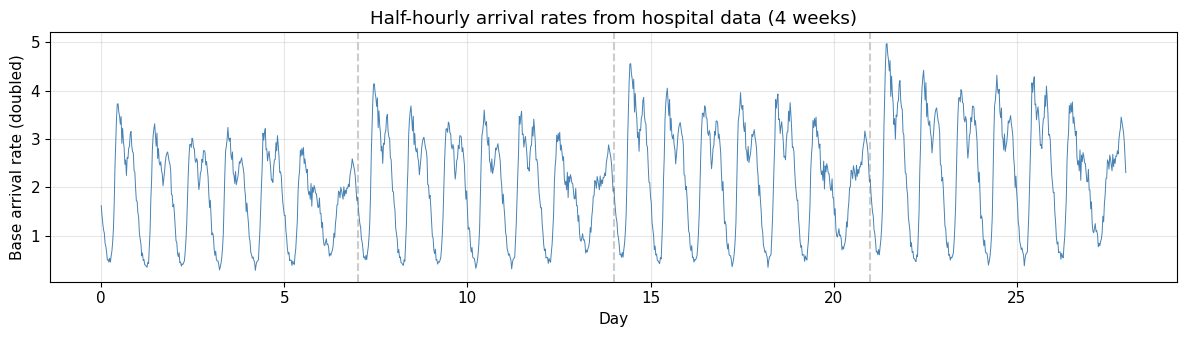

  lambda_k(k=0, p=1.0, t=  0.0) = 3.2395
  lambda_k(k=0, p=1.0, t= 12.0) = 6.9384
  lambda_k(k=0, p=1.0, t=100.0) = 0.9902
  lambda_k(k=0, p=1.0, t=400.0) = 4.7708

Windowed WDE estimates (UR, T=672.0):
  Kernel s=  12 hours (0.5 days):  WDE = -0.4461
  Kernel s=  24 hours (1.0 days):  WDE = -0.8292
  Kernel s=  48 hours (2.0 days):  WDE = -0.8108
  Kernel s= 168 hours (7.0 days):  WDE = -0.7992


In [43]:
from nonstationary_environment import (
    make_nonstationary_lambda,
    load_arrival_rates,
    DEFAULT_PARAMS,
)

# Build the real-data-driven non-stationary arrival rate function
lambda_ns = make_nonstationary_lambda()
ns_params = DEFAULT_PARAMS

print(f"Non-stationary environment parameters:")
print(f"  mu = {ns_params.mu}, p = {ns_params.p}, K = {ns_params.K}, zeta = {ns_params.zeta}")
print(f"  T_total = {ns_params.T_total} hours ({ns_params.T_total/24:.0f} days)")
print(f"  Week scalers = {ns_params.week_scalers}")

# Visualize the base arrival rates over 4 weeks
rates = load_arrival_rates()
time_axis = np.arange(len(rates)) * ns_params.block_length

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(time_axis / 24, rates, linewidth=0.7, color='steelblue')
ax.set_xlabel('Day')
ax.set_ylabel('Base arrival rate (doubled)')
ax.set_title('Half-hourly arrival rates from hospital data (4 weeks)')
ax.grid(True, alpha=0.3)
for week in range(1, 4):
    ax.axvline(week * 7, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Quick check: arrival rate at a few points
for t_check in [0.0, 12.0, 100.0, 400.0]:
    print(f"  lambda_k(k=0, p=1.0, t={t_check:5.1f}) = {lambda_ns(0, 1.0, t_check):.4f}")

# User-randomized experiment under non-stationarity with real data
log_ns = simulate_user_level(
    lambda_k=lambda_ns, mu=ns_params.mu, p=ns_params.p, zeta=ns_params.zeta,
    T=ns_params.T_total, K=ns_params.K, seed=42, time_varying=True
)

# Windowed WDE with different kernel lengths
print(f"\nWindowed WDE estimates (UR, T={ns_params.T_total}):")
for s in [12, 24, 48, 168]:
    est = wde_estimator_nonstationary_user_level(log_ns, kernel_length=s)
    print(f'  Kernel s={s:4d} hours ({s/24:.1f} days):  WDE = {est:.4f}')

In [44]:
# === Pre-compute proxy true V'(p) via paired simulation under two prices ===
# Instead of using the UR WDE estimator, we directly simulate the queue under
# two fixed prices (p + delta) and (p - delta), measure the throughput
# (arrivals / time) from each, and estimate V'(p) as:
#     V'(p) ≈ (lambda_bar(p + delta) - lambda_bar(p - delta)) / (2 * delta)
# We repeat this many times with independent seeds and average.

from congestion_experiments.simulator import QueueSimulator
from tqdm.notebook import tqdm

def simulate_fixed_price(lambda_k, mu, p_fixed, T, K, seed, time_varying=False):
    """Simulate a queue under a single fixed price and return throughput.
    
    Throughput = (number of arrivals) / T.
    """
    sim = QueueSimulator(lambda_k, mu, K=K, time_varying=time_varying)
    rng = np.random.default_rng(seed)
    
    # Constant price schedule: always return (p_fixed, +1) — treatment label
    # is irrelevant here since we're just measuring throughput.
    def price_schedule(t, q):
        return p_fixed, 1
    
    log = sim._run(T, price_schedule, rng, q0=0)
    n_arrivals = np.sum(log.event_types == 1)
    return n_arrivals / T

def compute_proxy_Vprime(lambda_k, mu, p, delta, T_proxy, n_reps_proxy,
                         K=K_MAX, time_varying=False, label=''):
    """Estimate V'(p) by running paired simulations at p ± delta.
    
    For each replication:
      1. Simulate queue at price (p + delta) → measure throughput λ̄₊
      2. Simulate queue at price (p - delta) → measure throughput λ̄₋
      3. Estimate V'(p) ≈ (λ̄₊ - λ̄₋) / (2δ)
    
    Average over all replications.
    """
    estimates = []
    for rep in tqdm(range(n_reps_proxy), desc=label, unit='rep'):
        # Use paired seeds: same base seed, different sub-seeds for +/-
        seed_plus  = rep * 7919 + 31
        seed_minus = rep * 7919 + 32
        
        throughput_plus  = simulate_fixed_price(
            lambda_k, mu, p + delta, T_proxy, K, seed_plus, time_varying)
        throughput_minus = simulate_fixed_price(
            lambda_k, mu, p - delta, T_proxy, K, seed_minus, time_varying)
        
        vprime_est = (throughput_plus - throughput_minus) / (2 * delta)
        estimates.append(vprime_est)
    
    estimates = np.array(estimates)
    proxy_val = np.mean(estimates)
    proxy_se = np.std(estimates) / np.sqrt(n_reps_proxy)
    print(f'{label}:')
    print(f'  Proxy V\'(p) = {proxy_val:.6f}  (SE = {proxy_se:.6f}, '
          f'n_reps = {n_reps_proxy}, T = {T_proxy}, delta = {delta})')
    return proxy_val

print('Computing proxy true V\'(p) via paired fixed-price simulations...\n')

# Power-law model (stationary)
true_Vprime_pl = compute_proxy_Vprime(
    lambda_power_law, mu=1.0, p=p, delta=0.01,
    T_proxy=50000, n_reps_proxy=500, K=K_MAX,
    time_varying=False, label='Power-law (stationary)'
)

# Non-stationary environment with real hospital data
true_Vprime_ns = compute_proxy_Vprime(
    lambda_ns, mu=ns_params.mu, p=ns_params.p, delta=0.01,
    T_proxy=ns_params.T_total, n_reps_proxy=50000, K=ns_params.K,
    time_varying=True, label='Real-data non-stationary environment'
)

print(f'\nFor reference, analytic V\'(p) for stationary ZI-M/M/1 = {true_Vprime_zi:.6f}')

Computing proxy true V'(p) via paired fixed-price simulations...



Power-law (stationary):   0%|          | 0/500 [00:00<?, ?rep/s]

Power-law (stationary):
  Proxy V'(p) = -0.136364  (SE = 0.012186, n_reps = 500, T = 50000, delta = 0.01)


Real-data non-stationary environment:   0%|          | 0/50000 [00:00<?, ?rep/s]

Real-data non-stationary environment:
  Proxy V'(p) = -0.527894  (SE = 0.012560, n_reps = 50000, T = 672.0, delta = 0.01)

For reference, analytic V'(p) for stationary ZI-M/M/1 = -0.319933


---
## 3. Simulation Study

We compare the three estimators across experimental designs (interval switchback vs. user-randomized) and arrival rate models (zero-deflated M/M/1 vs. power law), in both stationary and non-stationary settings.

### 3.1 Stationary Zero-Deflated M/M/1 Queue

In [45]:
def run_simulation_study(lambda_k, mu, p, zeta, T, K, n_reps, true_Vprime,
                         interval_length=100, time_varying=False, label=''):
    """Run n_reps replications and collect estimator values."""
    results = {
        'IS_mf': [], 'IS_it': [], 'IS_wde': [],
        'UR_wde': [],
    }
    for rep in range(n_reps):
        seed = rep * 1000 + 7
        # Interval switchback
        log_is = simulate_interval_switchback(
            lambda_k, mu, p, zeta, T, interval_length, K=K, seed=seed,
            time_varying=time_varying
        )
        s_is = compute_summary_stats(log_is)
        results['IS_mf'].append(model_free_estimator(s_is))
        results['IS_it'].append(idle_time_estimator(s_is))
        results['IS_wde'].append(wde_estimator(s_is))

        # User-randomized
        log_ur = simulate_user_level(
            lambda_k, mu, p, zeta, T, K=K, seed=seed,
            time_varying=time_varying
        )
        s_ur = compute_summary_stats(log_ur)
        results['UR_wde'].append(wde_estimator_user_level(s_ur))

    # Convert to arrays
    for k in results:
        results[k] = np.array(results[k])

    # Print summary table
    print(f'\n{"=" * 60}')
    print(f'  {label}  (T={T}, n_reps={n_reps}, true V\' = {true_Vprime})')
    print(f'{"=" * 60}')
    print(f'{"Estimator":<28s} {"Mean":>8s} {"Bias":>8s} {"Std":>8s} {"RMSE":>8s}')
    print('-' * 60)
    for name, key in [('IS: Model-free', 'IS_mf'),
                       ('IS: Idle-time', 'IS_it'),
                       ('IS: WDE', 'IS_wde'),
                       ('UR: WDE', 'UR_wde')]:
        vals = results[key]
        bias = np.mean(vals) - true_Vprime if true_Vprime is not None else np.nan
        std = np.std(vals)
        rmse = np.sqrt(bias**2 + std**2) if true_Vprime is not None else std
        print(f'{name:<28s} {np.mean(vals):>8.4f} {bias:>8.4f} {std:>8.4f} {rmse:>8.4f}')

    return results

In [46]:
# --- Stationary zero-deflated M/M/1 ---
results_zi = run_simulation_study(
    lambda_k=lambda_zi_mm1, mu=1.0, p=p, zeta=zeta,
    T=2000, K=K_MAX, n_reps=1000, true_Vprime=true_Vprime_zi,
    interval_length=100, label='Stationary zero-deflated M/M/1 queue'
)


  Stationary zero-deflated M/M/1 queue  (T=2000, n_reps=1000, true V' = -0.31993261484286606)
Estimator                        Mean     Bias      Std     RMSE
------------------------------------------------------------
IS: Model-free                -0.3416  -0.0216   0.2897   0.2905
IS: Idle-time                 -0.3149   0.0050   0.2221   0.2222
IS: WDE                       -0.3379  -0.0180   0.1740   0.1749
UR: WDE                       -0.3221  -0.0022   0.1605   0.1605


In [47]:
# --- Stationary power-law queue ---
results_pl = run_simulation_study(
    lambda_k=lambda_power_law, mu=1.0, p=p, zeta=zeta,
    T=2000, K=15, n_reps=1000, true_Vprime=true_Vprime_pl,
    interval_length=100, label='Stationary power-law queue'
)
# true V'(p) estimated via large-scale simulation (see proxy computation above)


  Stationary power-law queue  (T=2000, n_reps=1000, true V' = -0.1363640000000002)
Estimator                        Mean     Bias      Std     RMSE
------------------------------------------------------------
IS: Model-free                -0.2614  -0.1251   0.4021   0.4211
IS: Idle-time                 -0.1335   0.0029   0.1148   0.1149
IS: WDE                       -0.1616  -0.0253   0.1001   0.1032
UR: WDE                       -0.1504  -0.0140   0.0866   0.0877


/var/folders/ht/40d9rvcd6hd6zz_klrm6hkxr0000gn/T/ipykernel_11229/1628045369.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,
/var/folders/ht/40d9rvcd6hd6zz_klrm6hkxr0000gn/T/ipykernel_11229/1628045369.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,


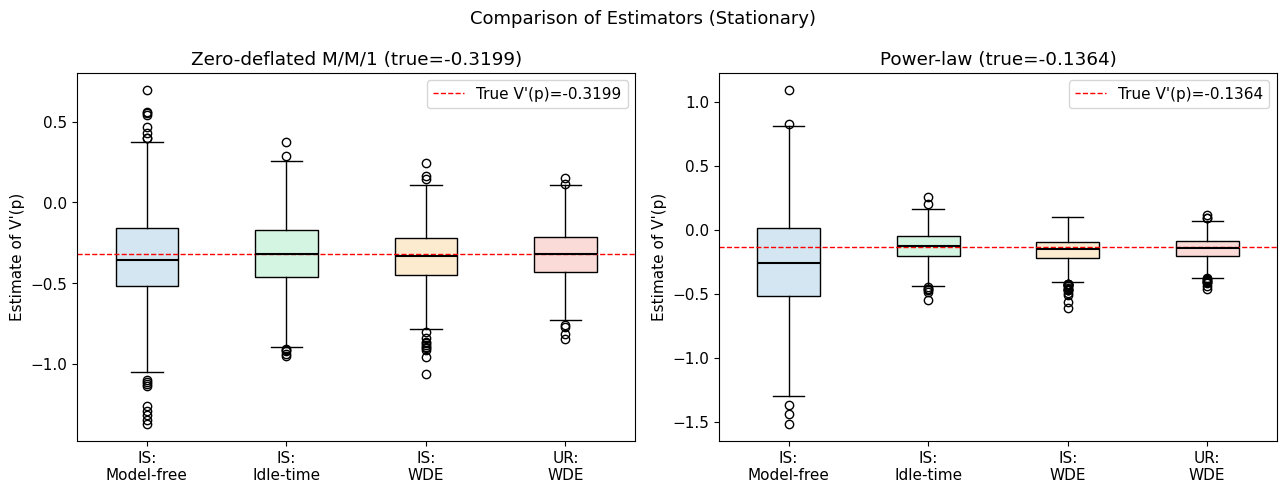

In [48]:
# --- Visualization: boxplots ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, results, title, true_val in [
    (axes[0], results_zi, f'Zero-deflated M/M/1 (true={true_Vprime_zi:.4f})', true_Vprime_zi),
    (axes[1], results_pl, f'Power-law (true={true_Vprime_pl:.4f})', true_Vprime_pl),
]:
    data = [results['IS_mf'], results['IS_it'],
            results['IS_wde'], results['UR_wde']]
    labels = ['IS:\nModel-free', 'IS:\nIdle-time',
              'IS:\nWDE', 'UR:\nWDE']
    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 1.5})
    colors = ['#d4e6f1', '#d5f5e3', '#fdebd0', '#fadbd8']
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
    if true_val is not None:
        ax.axhline(true_val, color='red', linestyle='--', linewidth=1, label=f"True V'(p)={true_val:.4f}")
        ax.legend()
    ax.set_title(title)
    ax.set_ylabel("Estimate of V'(p)")

plt.suptitle('Comparison of Estimators (Stationary)', fontsize=13)
plt.tight_layout()
plt.savefig('comparison_stationary.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Non-Stationary Environment (Real Hospital Data)

We use the real-data non-stationary environment (hospital ED arrival rates from `data0.csv`) and compare switchback vs. user-randomized designs, using the windowed WDE estimator.

In [52]:
def run_nonstationary_study(lambda_k, mu, p, zeta, T, K, n_reps,
                            true_Vprime, kernel_lengths, label=''):
    """Compare IS (model-free, idle-time with kernel=T) across interval
    lengths, and UR WDE across kernel lengths, in non-stationary settings."""
    results = {}

    # IS with different interval lengths: model-free, idle-time (kernel=T)
    il_values = [1, 2, 4, 6, 12, 24, 48, 84, 168]
    for il in il_values:
        key_mf  = f'IS_mf_il{il}'
        key_it  = f'IS_it_il{il}'
        results[key_mf]  = []
        results[key_it]  = []
        for rep in range(n_reps):
            seed = rep * 1000 + 13
            log = simulate_interval_switchback(
                lambda_k, mu, p, zeta, T, il, K=K, seed=seed,
                time_varying=True
            )
            stats = compute_summary_stats(log)
            results[key_mf].append(model_free_estimator(stats))
            results[key_it].append(idle_time_estimator(stats))

    # UR WDE with finer kernel lengths
    for kl in kernel_lengths:
        key = f'UR_wde_kl{kl}'
        results[key] = []
        for rep in range(n_reps):
            seed = rep * 1000 + 13
            log = simulate_user_level(
                lambda_k, mu, p, zeta, T, K=K, seed=seed,
                time_varying=True
            )
            est = wde_estimator_nonstationary_user_level(log, kernel_length=kl)
            results[key].append(est)

    # Convert to arrays
    for k in results:
        results[k] = np.array(results[k])

    # Summary
    print(f'\n{"=" * 70}')
    print(f'  {label}  (T={T}, n_reps={n_reps}, true V\' = {true_Vprime:.4f})')
    print(f'{"=" * 70}')
    print(f'{"Design + Estimator":<35s} {"Mean":>8s} {"Bias":>8s} {"Std":>8s} {"RMSE":>8s}')
    print('-' * 70)

    # Report IS: model-free and idle-time only
    for il in il_values:
        for prefix, name in [('IS_mf_il', 'IS: MF'), ('IS_it_il', 'IS: IT')]:
            key = f'{prefix}{il}'
            vals = results[key]
            bias = np.mean(vals) - true_Vprime
            std_val = np.std(vals)
            rmse = np.sqrt(bias**2 + std_val**2)
            print(f'{name + " il=" + str(il):<35s} {np.mean(vals):>8.4f} {bias:>8.4f} {std_val:>8.4f} {rmse:>8.4f}')

    print()
    # Report UR WDE
    for kl in kernel_lengths:
        key = f'UR_wde_kl{kl}'
        vals = results[key]
        bias = np.mean(vals) - true_Vprime
        std_val = np.std(vals)
        rmse = np.sqrt(bias**2 + std_val**2)
        print(f'{"UR: WDE kl=" + str(kl):<35s} {np.mean(vals):>8.4f} {bias:>8.4f} {std_val:>8.4f} {rmse:>8.4f}')

    return results

In [53]:
# Non-stationary environment with real hospital arrival data
# true V'(p) estimated via large-scale simulation (see proxy computation above)

results_ns = run_nonstationary_study(
    lambda_k=lambda_ns,
    mu=ns_params.mu, p=ns_params.p, zeta=ns_params.zeta,
    T=ns_params.T_total, K=ns_params.K,
    n_reps=1000, true_Vprime=true_Vprime_ns,
    kernel_lengths=[1, 2, 4, 6, 12, 24, 48, 84, 168, 336],
    label='Non-stationary (real hospital data)'
)


  Non-stationary (real hospital data)  (T=672.0, n_reps=1000, true V' = -0.5279)
Design + Estimator                      Mean     Bias      Std     RMSE
----------------------------------------------------------------------
IS: MF il=1                          -0.9944  -0.4665   0.5038   0.6866
IS: IT il=1                          -0.2832   0.2447   0.3473   0.4249
IS: MF il=2                          -0.9535  -0.4257   0.5292   0.6791
IS: IT il=2                          -0.3592   0.1687   0.3539   0.3920
IS: MF il=4                          -0.7690  -0.2411   0.5811   0.6291
IS: IT il=4                          -0.4139   0.1140   0.4021   0.4180
IS: MF il=6                          -0.7655  -0.2376   0.5676   0.6153
IS: IT il=6                          -0.4534   0.0745   0.3995   0.4064
IS: MF il=12                         -0.6568  -0.1289   0.5348   0.5501
IS: IT il=12                         -0.4721   0.0558   0.4743   0.4776
IS: MF il=24                         -0.5673  -0.0394  

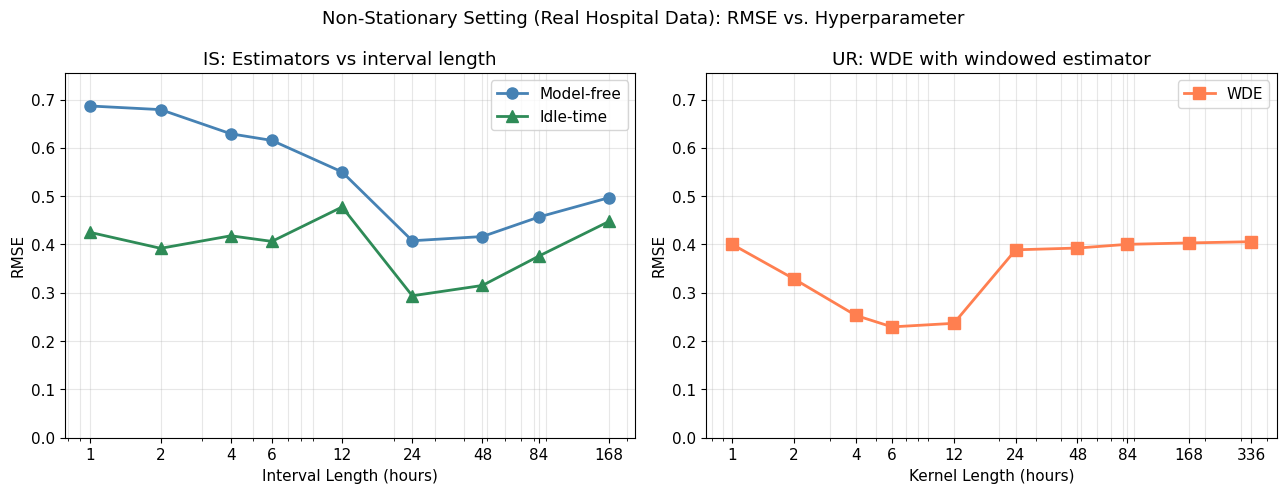

In [54]:
# --- Visualization: RMSE comparison ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: IS estimators (model-free, idle-time) vs interval length
il_values = [1, 2, 4, 6, 12, 24, 48, 84, 168]

for est_name, prefix, color, marker in [
    ('Model-free', 'IS_mf_il', 'steelblue', 'o'),
    ('Idle-time',  'IS_it_il', 'seagreen', '^'),
]:
    rmse_vals = []
    for il in il_values:
        vals = results_ns[f'{prefix}{il}']
        bias = np.mean(vals) - true_Vprime_ns
        rmse_vals.append(np.sqrt(bias**2 + np.var(vals)))
    axes[0].plot(il_values, rmse_vals, f'{marker}-', color=color,
                 linewidth=2, markersize=8, label=est_name)

axes[0].set_xscale('log')
axes[0].set_xticks(il_values)
axes[0].set_xticklabels(il_values)
axes[0].set_xlabel('Interval Length (hours)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('IS: Estimators vs interval length')
axes[0].legend()
axes[0].grid(True, alpha=0.3, which='both')

# Right: UR WDE vs kernel length
kl_values = [1, 2, 4, 6, 12, 24, 48, 84, 168, 336]
rmse_ur = []
for kl in kl_values:
    vals = results_ns[f'UR_wde_kl{kl}']
    bias = np.mean(vals) - true_Vprime_ns
    rmse_ur.append(np.sqrt(bias**2 + np.var(vals)))

axes[1].plot(kl_values, rmse_ur, 's-', color='coral', linewidth=2, markersize=8, label='WDE')
axes[1].set_xscale('log')
axes[1].set_xticks(kl_values)
axes[1].set_xticklabels(kl_values)
axes[1].set_xlabel('Kernel Length (hours)')
axes[1].set_ylabel('RMSE')
axes[1].set_title('UR: WDE with windowed estimator')
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

# Shared y-axis range
all_rmse = []
for prefix in ['IS_mf_il', 'IS_it_il']:
    for il in il_values:
        vals = results_ns[f'{prefix}{il}']
        bias = np.mean(vals) - true_Vprime_ns
        all_rmse.append(np.sqrt(bias**2 + np.var(vals)))
all_rmse.extend(rmse_ur)
y_max = max(all_rmse) * 1.1
axes[0].set_ylim(0, y_max)
axes[1].set_ylim(0, y_max)

plt.suptitle('Non-Stationary Setting (Real Hospital Data): RMSE vs. Hyperparameter', fontsize=13)
plt.tight_layout()
plt.savefig('comparison_nonstationary.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Variance Estimator Accuracy

We check that the plug-in variance estimators are well-calibrated by comparing their predictions to the empirical variance from repeated simulations.

In [55]:
# Collect variance estimates and compare to empirical variance
T_val = 2000
zeta_val = zeta

est_vars_mf  = []
est_vars_it  = []
est_vars_wde = []

for rep in range(1000):
    seed = rep * 1000 + 7
    log = simulate_interval_switchback(
        lambda_zi_mm1, mu=1.0, p=p, zeta=zeta_val,
        T=T_val, interval_length=100, K=K_MAX, seed=seed
    )
    s = compute_summary_stats(log)
    est_vars_mf.append(variance_model_free(s))
    est_vars_it.append(variance_idle_time(s))
    est_vars_wde.append(variance_wde(s))

# Empirical variance * T * zeta^2 gives the scaled variance
scale = T_val * zeta_val**2
emp_var_mf  = np.var(results_zi['IS_mf']) * scale
emp_var_it  = np.var(results_zi['IS_it']) * scale
emp_var_wde = np.var(results_zi['IS_wde']) * scale

print('Variance estimator calibration (zero-deflated M/M/1, T=2000):')
print(f'{"":<15s} {"Mean est":>10s} {"Empirical":>10s}')
print(f'{"Model-free":<15s} {np.mean(est_vars_mf):>10.4f} {emp_var_mf:>10.4f}')
print(f'{"Idle-time":<15s} {np.mean(est_vars_it):>10.4f} {emp_var_it:>10.4f}')
print(f'{"WDE":<15s} {np.mean(est_vars_wde):>10.4f} {emp_var_wde:>10.4f}')


Variance estimator calibration (zero-deflated M/M/1, T=2000):
                  Mean est  Empirical
Model-free          0.4178     0.4196
Idle-time           0.2611     0.2466
WDE                 0.1305     0.1513


### 3.4 Coverage of Confidence Intervals

In [56]:
# Check 95% CI coverage for zero-deflated M/M/1
true_val = true_Vprime_zi
coverage = {'mf': 0, 'it': 0, 'wde': 0}
n_reps_cov = 1000

for rep in range(n_reps_cov):
    seed = rep * 1000 + 7
    log = simulate_interval_switchback(
        lambda_zi_mm1, mu=1.0, p=p, zeta=zeta_val,
        T=T_val, interval_length=100, K=K_MAX, seed=seed
    )
    s = compute_summary_stats(log)

    for name, est_fn, var_fn in [
        ('mf',  model_free_estimator, variance_model_free),
        ('it',  idle_time_estimator,  variance_idle_time),
        ('wde', wde_estimator,        variance_wde),
    ]:
        est = est_fn(s)
        v = var_fn(s)
        lo, hi = confidence_interval(est, v, T_val, zeta_val, alpha=0.05)
        if lo <= true_val <= hi:
            coverage[name] += 1

print(f'95% CI coverage (zero-deflated M/M/1, T={T_val}, {n_reps_cov} reps):')
for name, label in [('mf', 'Model-free'), ('it', 'Idle-time'), ('wde', 'WDE')]:
    print(f'  {label:<15s}: {coverage[name]/n_reps_cov:.1%}')


95% CI coverage (zero-deflated M/M/1, T=2000, 1000 reps):
  Model-free     : 94.8%
  Idle-time      : 95.1%
  WDE            : 93.0%


---
## Summary

Key takeaways from the simulations:

1. **WDE dominates**: The weighted direct-effect estimator generally has the lowest variance.
2. **User-randomized (UR) helps**: The UR design with WDE achieves lower RMSE than switchback designs.
3. **Non-stationary robustness**: In non-stationary settings, user-randomized with windowed WDE is more robust to hyperparameter choices than interval switchbacks.
4. **Variance estimators are well-calibrated**: The plug-in variance formulae closely match empirical variances.